# Test No.1: Training and testing the newly refactored Classifer

## Imports before training

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from src.classifiers import (
    ResNet18_CBAM,
    CelebADataset,
    inference_single_image,
    visualize_integrated_gradients,
    SELECTED_ATTRIBUTES,
 )
from src.classifiers.trainer.training_script import train_resnet18_cbam

## Configs and functions Dataloader preparations

In [2]:
# --- CONFIGURATION ---
BATCH_SIZE = 128
IMAGE_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"./Dataset/celeba_70percent_721/train/list_attr_celeba.csv"
IMAGE_PATH = r"./Dataset/celeba_70percent_721/train/img_align_celeba"
PATH_CHECKPOINT = r"./outputs/classifier/checkpoints/resnet18_cbam_128_05_3"
NUM_CLASSES = len(SELECTED_ATTRIBUTES)
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
WEIGHT_DECAY = 1e-4

# Tạo thư mục checkpoint
os.makedirs(PATH_CHECKPOINT, exist_ok=True)

In [3]:
# Load CSV
print("Loading CSV metadata...")
df_attr = pd.read_csv(CSV_PATH, index_col=0)
missing_attrs = [attr for attr in SELECTED_ATTRIBUTES if attr not in df_attr.columns]
if missing_attrs:
    raise ValueError(f"Missing required CelebA attributes: {missing_attrs}")
df_attr = df_attr.loc[:, SELECTED_ATTRIBUTES]
attribute_names = SELECTED_ATTRIBUTES

# Split Train/Val (90/10)
train_df, val_df = train_test_split(df_attr, test_size=0.1, random_state=42)

# Tính toán pos_weight cho Loss Function dựa trên tập Train
# pos_weight = (num_neg) / (num_pos) cho từng class
print("Calculating positive weights for loss function...")
train_labels = train_df.replace(-1, 0).values
num_pos = np.sum(train_labels, axis=0)
num_neg = len(train_df) - num_pos
# Thêm epsilon để tránh chia cho 0
pos_weights_tensor = torch.tensor(num_neg / (num_pos + 1e-5), dtype=torch.float32).to(DEVICE)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

viz_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

train_dataset = CelebADataset(train_df, IMAGE_PATH, transform=train_transform)
val_dataset = CelebADataset(val_df, IMAGE_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

Loading CSV metadata...
Calculating positive weights for loss function...
Train size: 89344 | Val size: 9928


In [4]:
# --- 3. MODEL, OPTIMIZER, LOSS SETUP ---

print(f"Initializing ResNet18 + CBAM on {DEVICE}...")
model = ResNet18_CBAM(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Loss function với pos_weight xử lý imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Initializing ResNet18 + CBAM on cuda...


## Training the model

In [5]:
# --- 4. TRAINING LOOP ---
print("Starting training loop...")

history = train_resnet18_cbam(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    attribute_names=attribute_names,
    checkpoint_dir=PATH_CHECKPOINT,
    checkpoint_prefix="resnet18_cbam",
    save_every=5,
    threshold=0.5,
)

Starting training loop...


Epoch 1/5 [Val]: 100%|██████████| 78/78 [00:57<00:00,  1.36it/s]



--- Epoch 1 Report ---
LR: 0.001000 | Train Loss: 0.3754 | Val Loss: 0.3468 | Mean Val Acc: 0.8959
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9782     | 0.0445
Bangs                     | 0.9336     | 0.2127
Black_Hair                | 0.8824     | 0.2248
Blond_Hair                | 0.9100     | 0.2465
Brown_Hair                | 0.6981     | 0.4896
Bushy_Eyebrows            | 0.8796     | 0.2419
Eyeglasses                | 0.9912     | 0.0723
Male                      | 0.9620     | 0.4432
Mouth_Slightly_Open       | 0.9253     | 0.5033
Mustache                  | 0.9144     | 0.1362
Pale_Skin                 | 0.8918     | 0.1596
Young                     | 0.7843     | 0.6328
------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 78/78 [00:43<00:00,  1.79it/s]



--- Epoch 2 Report ---
LR: 0.001000 | Train Loss: 0.3105 | Val Loss: 0.3162 | Mean Val Acc: 0.9059
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9488     | 0.0764
Bangs                     | 0.9403     | 0.1969
Black_Hair                | 0.8722     | 0.3280
Blond_Hair                | 0.9387     | 0.1958
Brown_Hair                | 0.7977     | 0.3645
Bushy_Eyebrows            | 0.8794     | 0.2405
Eyeglasses                | 0.9920     | 0.0758
Male                      | 0.9695     | 0.4351
Mouth_Slightly_Open       | 0.9274     | 0.4546
Mustache                  | 0.9082     | 0.1347
Pale_Skin                 | 0.8899     | 0.1633
Young                     | 0.8066     | 0.6377
------------------------------------------------------------


...


--- Epoch 3 Report ---
LR: 0.001000 | Train Loss: 0.2939 | Val Loss: 0.3076 | Mean Val Acc: 0.8930
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9509     | 0.0740
Bangs                     | 0.9201     | 0.2328
Black_Hair                | 0.8813     | 0.3071
Blond_Hair                | 0.9118     | 0.2416
Brown_Hair                | 0.7987     | 0.3621
Bushy_Eyebrows            | 0.8142     | 0.3362
Eyeglasses                | 0.9899     | 0.0804
Male                      | 0.9707     | 0.4212
Mouth_Slightly_Open       | 0.9279     | 0.4746
Mustache                  | 0.9015     | 0.1433
Pale_Skin                 | 0.8391     | 0.2161
Young                     | 0.8094     | 0.6361
------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 78/78 [00:58<00:00,  1.34it/s]



--- Epoch 4 Report ---
LR: 0.001000 | Train Loss: 0.2793 | Val Loss: 0.3080 | Mean Val Acc: 0.9047
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9786     | 0.0402
Bangs                     | 0.9354     | 0.2107
Black_Hair                | 0.8852     | 0.3174
Blond_Hair                | 0.9115     | 0.2354
Brown_Hair                | 0.8137     | 0.3475
Bushy_Eyebrows            | 0.7912     | 0.3537
Eyeglasses                | 0.9874     | 0.0817
Male                      | 0.9772     | 0.4181
Mouth_Slightly_Open       | 0.9326     | 0.4627
Mustache                  | 0.9192     | 0.1240
Pale_Skin                 | 0.9321     | 0.1046
Young                     | 0.7927     | 0.5880
------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 78/78 [00:40<00:00,  1.93it/s]


--- Epoch 5 Report ---
LR: 0.001000 | Train Loss: 0.2688 | Val Loss: 0.3102 | Mean Val Acc: 0.9134
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9780     | 0.0409
Bangs                     | 0.9358     | 0.2084
Black_Hair                | 0.8572     | 0.3581
Blond_Hair                | 0.9421     | 0.1921
Brown_Hair                | 0.8105     | 0.3513
Bushy_Eyebrows            | 0.8574     | 0.2752
Eyeglasses                | 0.9850     | 0.0828
Male                      | 0.9707     | 0.4027
Mouth_Slightly_Open       | 0.9333     | 0.4711
Mustache                  | 0.9337     | 0.1037
Pale_Skin                 | 0.9124     | 0.1301
Young                     | 0.8444     | 0.6891
------------------------------------------------------------
Saved checkpoint: ./outputs/classifier/checkpoints/resnet18_cbam_128_05_3\resnet1

## Saliency validation

In [7]:
# --- 5. INFERENCE ON SINGLE IMAGE ---
print("Loading best model for inference...")
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth"), map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Chọn 1 ảnh ngẫu nhiên từ validation set để test
sample_img_name = val_df.index[320]  # Lấy ảnh bất kỳ trong val set
sample_img_path = os.path.join(IMAGE_PATH, sample_img_name)

print(f"Testing inference on: {sample_img_name}")

# Run inference (threshold 0.5)
probs, preds, gt = inference_single_image(
    model=model,
    image_path=sample_img_path,
    transform=val_transform,
    attribute_names=attribute_names,
    device=DEVICE,
    df_attr=df_attr,
    threshold=0.5
)

# --- TEST VỚI NHIỀU ẢNH (Optional) ---
print("\n" + "="*80)
print("Testing on multiple random images from validation set:")
print("="*80)

np.random.seed(42)
random_indices = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for idx in random_indices:
    img_name = val_df.index[idx]
    img_path = os.path.join(IMAGE_PATH, img_name)
    
    inference_single_image(
        model=model,
        image_path=img_path,
        transform=val_transform,
        attribute_names=attribute_names,
        device=DEVICE,
        df_attr=df_attr,
        threshold=0.9
)

Loading best model for inference...
Testing inference on: 084250.jpg

Inference Result for: 084250.jpg
Attribute                 | Ground Truth  | Pred Prob  | Prediction  | Correct
--------------------------------------------------------------------------------
Bald                      | 0             | 0.0000     | 0           | ✓      
Bangs                     | 0             | 0.0007     | 0           | ✓      
Black_Hair                | 0             | 0.1777     | 0           | ✓      
Blond_Hair                | 0             | 0.0010     | 0           | ✓      
Brown_Hair                | 1             | 0.8479     | 1           | ✓      
Bushy_Eyebrows            | 0             | 0.0704     | 0           | ✓      
Eyeglasses                | 0             | 0.0000     | 0           | ✓      
Male                      | 0             | 0.0000     | 0           | ✓      
Mouth_Slightly_Open       | 1             | 0.5290     | 1           | ✓      
Mustache                  

Visualizing Integrated Gradients for attribute: Brown_Hair

=== Integrated Gradients for POSITIVE class ===


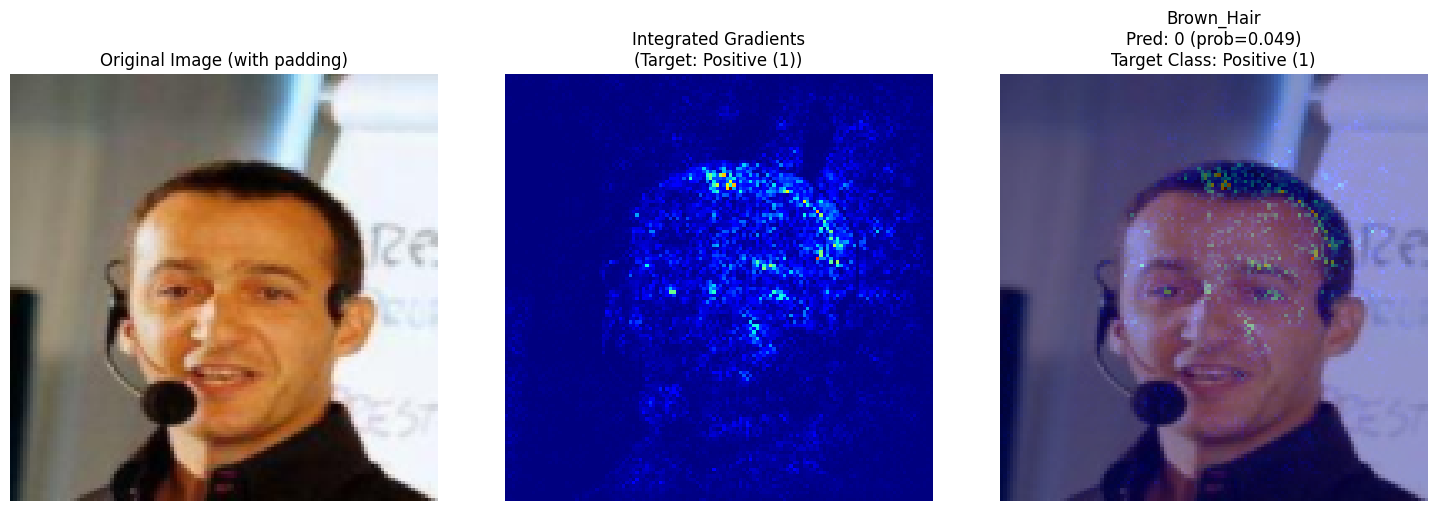


=== Integrated Gradients for NEGATIVE class ===


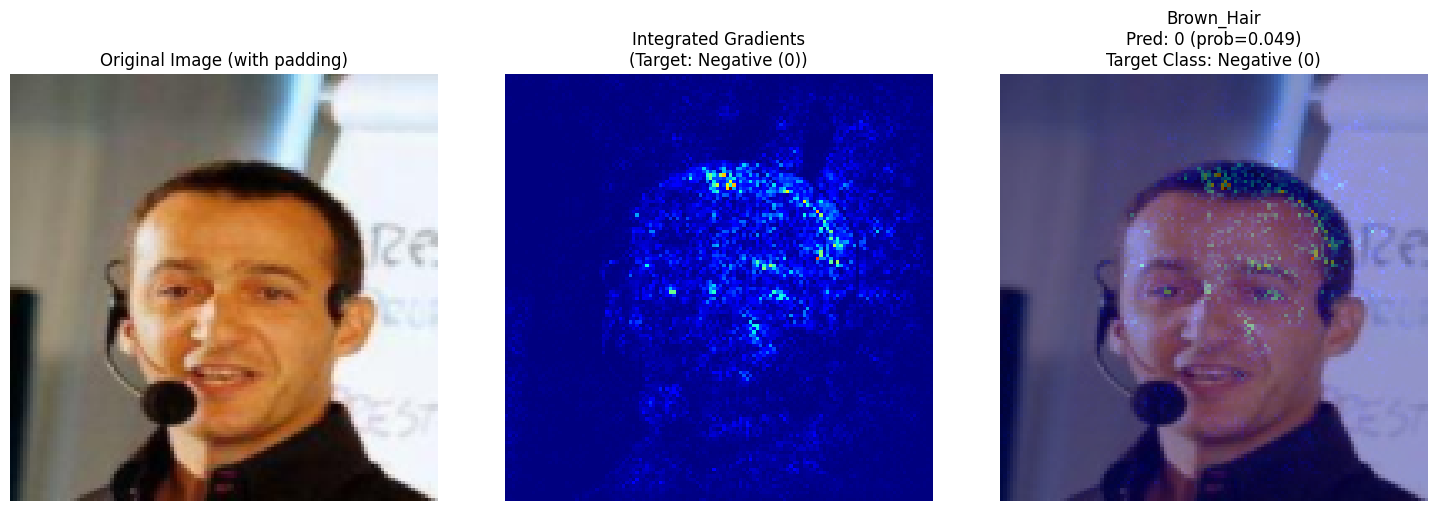

In [8]:
# --- 8. INTEGRATED GRADIENTS ---
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[127])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Integrated Gradients for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Integrated Gradients for POSITIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=1,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Visualize for NEGATIVE class
print("\n=== Integrated Gradients for NEGATIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=0,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Test No.2: Training and testing the newly refactored vq_vae

### HR-VQGAN Training Setup
Initialize and configure the HR-VQGAN (Hierarchical Residual VQ-VAE with Discriminator) for unsupervised training on CelebA.

In [1]:
import torch
from src.latentspace.config import cfg
from src.latentspace.trainer import train

# ============================================================================
# HVQ-GAN Training V3 - Step-based Unsupervised Training
# ============================================================================

print("="*70)
print("HVQ-GAN TRAINING V3")
print("="*70)

# Configuration
cfg.total_steps = 50000        # Total training steps
cfg.batch_size = 16             # Batch size
cfg.save_interval = 2500        # Save checkpoint every 2500 steps
cfg.sample_interval = 1000     # INCREASE: Sample every 1000 steps (less frequent)
cfg.log_interval = 1           # Log every 1 step
cfg.num_samples = 8
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"
cfg.data_path = "./Dataset/celeba_70percent_721/train"
cfg.save_dir = "./outputs/latent_space/hrvqvae(rerun)"
cfg.disc_start_step = 40000      # Start discriminator after 40000 steps warmup
cfg.use_amp = False             # DISABLE AMP initially (causing overflow)

print(f"\nConfiguration:")
print(f"   Device: {cfg.device}")
print(f"   Image Size: {cfg.image_size}x{cfg.image_size}")
print(f"   Batch Size: {cfg.batch_size}")
print(f"   Total Steps: {cfg.total_steps:,}")
print(f"   Log Interval: {cfg.log_interval} steps")
print(f"   Save Interval: {cfg.save_interval:,} steps")
print(f"   Sample Interval: {cfg.sample_interval:,} steps")
print(f"   Discriminator Start: Step {cfg.disc_start_step:,}")
print(f"   Learning Rate: {cfg.learning_rate}")
print(f"   Use AMP: {cfg.use_amp} (disabled for stability)")
print(f"   Loss Weights: {cfg.weights}")
print("="*70 + "\n")

# Verify data path
import os
if not os.path.exists(cfg.data_path):
    print(f"WARNING: Data path not found: {cfg.data_path}")
    print(f"Please update cfg.data_path to point to your CelebA dataset")
else:
    img_dir = os.path.join(cfg.data_path, "img_align_celeba")
    if os.path.exists(img_dir):
        num_images = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
        print(f"Found {num_images} training images")
    else:
        print(f"Image directory not found: {img_dir}")

print("\nStarting step-based training...\n")

try:
    train()
    print("\n" + "="*70)
    print("HVQ-GAN TRAINING COMPLETED!")
    print("="*70)
    print(f"\nCheckpoints saved to: {cfg.save_dir}")
    print(f"Samples saved to: {os.path.join(cfg.save_dir, 'samples')}")
    print(f"Logs saved to: {os.path.join(cfg.save_dir, 'logs')}")
except KeyboardInterrupt:
    print("\nTraining interrupted by user")
except Exception as e:
    print(f"\nTraining error: {e}")
    import traceback
    traceback.print_exc()

HVQ-GAN TRAINING V3

Configuration:
   Device: cuda
   Image Size: 128x128
   Batch Size: 16
   Total Steps: 50,000
   Log Interval: 1 steps
   Save Interval: 2,500 steps
   Sample Interval: 1,000 steps
   Discriminator Start: Step 40,000
   Learning Rate: 0.0003
   Use AMP: False (disabled for stability)
   Loss Weights: {'recon': 1.0, 'vq': 1.0, 'perceptual': 1.0, 'disc': 0.8}

Found 99272 training images

Starting step-based training...

🔧 HVQ-GAN TRAINING V3 (Step-based, Unsupervised)
Device: cuda
Total Steps: 50,000
Batch Size: 16
Log Interval: 1 steps
Save Interval: 2,500 steps
Sample Interval: 1,000 steps
📁 Output Directory: ./outputs/latent_space/hrvqvae(rerun)
   ├── checkpoints/              (model checkpoints)
   ├── samples/                  (progressive decoding visualizations)
   ├── metrics_and_visualisations/ (training metrics & analysis)
   └── logs/                     (training logs)



a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\latentspace\trainer.py:273: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler(enabled=cfg.use_amp)
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\latentspace\trainer.py:274: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler(enabled=cfg.use_amp)
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Cou

Loading VGG for Perceptual Loss...
✅ VGG loaded

Training images: 99272
Batches per cycle: 6205

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


...

Training: 100%|██████████| 50000/50000 [1:43:55<00:00,  5.21step/s, Tot=0.3048, Rec=0.0287, Rtot=0.4590, VQ=0.0397, Perc=0.3906, Ppl=204.51, LPIPS=0.0928, DiscG=2.1015, DiscD=0.8792] 


📊 CREATING EVALUATION REPORT AT STEP 50,000
✅ Loss curves saved: loss_curves_step_50000.png
✅ Metrics comparison saved: metrics_comparison_step_50000.png
✅ Cascade hierarchy saved: cascade_hierarchy_step_50000.png


Training: 100%|██████████| 50000/50000 [1:43:59<00:00,  8.01step/s, Tot=0.3048, Rec=0.0287, Rtot=0.4590, VQ=0.0397, Perc=0.3906, Ppl=204.51, LPIPS=0.0928, DiscG=2.1015, DiscD=0.8792]

✅ Codebook usage saved: codebook_usage_step_50000.png
✅ Codebook analysis saved: codebook_analysis_step_50000.txt

   Metrics history: metrics_history.csv

✅ Step 50,000 Checkpoint:
   Checkpoint: checkpoint_step_50000.pth
   Metrics: MSE=0.0287, PSNR=21.44 dB, SSIM=0.807, LPIPS=0.0928
   Codebook: Top usage=39.3%, Mid usage=100.0%, Bottom usage=100.0%

✅ HVQ-GAN TRAINING COMPLETED SUCCESSFULLY!

📁 Output Structure:
   ./outputs/latent_space/hrvqvae(rerun)/
   ├── checkpoints/
   │   ├── checkpoint_step_5000.pth
   │   ├── checkpoint_step_10000.pth
   │   └── model_latest.pth
   ├── samples/
   │   ├── progressive_step_2500_comparison.png
   │   ├── progressive_step_5000_comparison.png
   │   └── progressive_step_10000_comparison.png
   ├── metrics_and_visualisations/
   │   ├── loss_curves_step_5000.png
   │   ├── metrics_comparison_step_5000.png
   │   ├── cascade_hierarchy_step_5000.png
   │   ├── codebook_usage_step_5000.png
   │   ├── codebook_analysis_step_5000.txt
   │   └── met


HVQ-GAN TRAINING COMPLETED!

Checkpoints saved to: ./outputs/latent_space/hrvqvae(rerun)
Samples saved to: ./outputs/latent_space/hrvqvae(rerun)\samples
Logs saved to: ./outputs/latent_space/hrvqvae(rerun)\logs


## Latent space validation

In [6]:
# Run latent-space evaluation suite
import os
import sys
import torch
from pathlib import Path
import subprocess

# Update these paths as needed for your trained checkpoints
HVQ_CHECKPOINT = Path("./outputs/latent_space/hrvqvae/checkpoints/best_no_gan.pth")
CLASSIFIER_CHECKPOINT = Path("./outputs/classifier/checkpoints/resnet18_cbam_128_05_3/best_model.pth")
DATA_ROOT = Path("./Dataset/celeba_70percent_721/val")
ATTRIBUTE_CSV = DATA_ROOT / "list_attr_celeba.csv"
OUTPUT_DIR = Path("./outputs/testing_suite/hvq_eval(no_gan)")
if not HVQ_CHECKPOINT.exists():
    raise FileNotFoundError(f"HVQ checkpoint not found: {HVQ_CHECKPOINT}")
if CLASSIFIER_CHECKPOINT and not CLASSIFIER_CHECKPOINT.exists():
    raise FileNotFoundError(f"Classifier checkpoint not found: {CLASSIFIER_CHECKPOINT}")
if not ATTRIBUTE_CSV.exists():
    raise FileNotFoundError(f"Attribute CSV not found: {ATTRIBUTE_CSV}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

cmd = [
    sys.executable,
    "-m",
    "src.testing_suite.lspace_testing",
    "--model-ckpt", str(HVQ_CHECKPOINT),
    "--classifier-ckpt", str(CLASSIFIER_CHECKPOINT),
    "--data-root", str(DATA_ROOT),
    "--attribute-csv", str(ATTRIBUTE_CSV),
    "--output-dir", str(OUTPUT_DIR),
    "--device", "cuda" if torch.cuda.is_available() else "cpu",
    "--tensorboard",
    "--visual-interval", "200",
    "--fast-eval",
    "--lpips-interval", "2",
    "--semantic-interval", "2",
]

project_root = Path.cwd()
env = os.environ.copy()
env["PYTHONPATH"] = os.pathsep.join(
    filter(None, [str(project_root), env.get("PYTHONPATH")])
)

print("Launching latent space evaluation with command:\n", " ".join(str(x) for x in cmd))
result = subprocess.run(
    cmd,
    env=env,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)

if result.stdout:
    print("\n=== subprocess stdout ===\n", result.stdout)
if result.stderr:
    print("\n=== subprocess stderr ===\n", result.stderr)

if result.returncode != 0:
    raise subprocess.CalledProcessError(result.returncode, cmd, output=result.stdout, stderr=result.stderr)

print("Latent space evaluation completed successfully.")


Launching latent space evaluation with command:
 a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Scripts\python.exe -m src.testing_suite.lspace_testing --model-ckpt outputs\latent_space\hrvqvae\checkpoints\best_no_gan.pth --classifier-ckpt outputs\classifier\checkpoints\resnet18_cbam_128_05_3\best_model.pth --data-root Dataset\celeba_70percent_721\val --attribute-csv Dataset\celeba_70percent_721\val\list_attr_celeba.csv --output-dir outputs\testing_suite\hvq_eval(no_gan) --device cuda --tensorboard --visual-interval 200 --fast-eval --lpips-interval 2 --semantic-interval 2

=== subprocess stdout ===
 Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
Info: KID metric version does not support subset_replacement; r

## Classifier drop test to test the recon ability of the model

In [5]:
# Classifier drop test (recon fidelity gate)
import os
import sys
from pathlib import Path
import subprocess

# Update these paths to your checkpoints and data
VQVAE_CKPT = Path("./outputs/latent_space/hrvqvae/checkpoints/best_gan.pth")
CLASSIFIER_CKPT = Path("./outputs/classifier/checkpoints/resnet18_cbam_128_05_3/best_model.pth")
DATA_ROOT = Path("./Dataset/celeba_70percent_721/val")
ATTR_CSV = DATA_ROOT / "list_attr_celeba.csv"
OUTPUT_JSON = Path("./outputs/testing_suite/hrvqvae_tests(gan)/classifier_drop.json")

for p in (VQVAE_CKPT, CLASSIFIER_CKPT, DATA_ROOT, ATTR_CSV):
    if not p.exists():
        raise FileNotFoundError(f"Missing required path: {p}")

cmd = [
    sys.executable,
    "-m",
    "src.testing_suite.classifier_drop_test",
    "--vqvae-ckpt", str(VQVAE_CKPT),
    "--classifier-ckpt", str(CLASSIFIER_CKPT),
    "--data-root", str(DATA_ROOT),
    "--attribute-csv", str(ATTR_CSV),
    "--batch-size", "32",
    "--num-workers", "4",
    "--threshold", "0.5",
    "--max-samples", "512",  # quick sanity run; set None for full eval
    "--output", str(OUTPUT_JSON),
]

print("Running classifier drop test:\n", " ".join(str(x) for x in cmd))
result = subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")

if result.stdout:
    print("\n=== stdout ===\n", result.stdout)
if result.stderr:
    print("\n=== stderr ===\n", result.stderr)

if result.returncode != 0:
    raise subprocess.CalledProcessError(result.returncode, cmd, output=result.stdout, stderr=result.stderr)


Running classifier drop test:
 a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Scripts\python.exe -m src.testing_suite.classifier_drop_test --vqvae-ckpt outputs\latent_space\hrvqvae\checkpoints\best_gan.pth --classifier-ckpt outputs\classifier\checkpoints\resnet18_cbam_128_05_3\best_model.pth --data-root Dataset\celeba_70percent_721\val --attribute-csv Dataset\celeba_70percent_721\val\list_attr_celeba.csv --batch-size 32 --num-workers 4 --threshold 0.5 --max-samples 512 --output outputs\testing_suite\hrvqvae_tests(gan)\classifier_drop.json

=== stdout ===
 
=== Classifier Drop Test ===
Samples evaluated      : 512
Classifier accuracy    : 89.06% (original)
Accuracy after VQVAE   : 87.63% (recon)
Accuracy drop          : 1.43%
Decision               : proceed_to_mutator
Saved results to outputs\testing_suite\hrvqvae_tests(gan)\classifier_drop.json



# Test 3: Training Counterfactual Generator (ceGAN)
Initialize and train the comprehensive counterfactual generation model with logging, checkpointing, and visualization.

In [1]:
# Hyperparameter Initialization
from src.synthesis.config import Config
from src.synthesis.dataset import get_loader
from src.synthesis.trainer import Trainer

cfg = Config()
cfg.use_amp = False  # force full precision for stability
cfg.decoder_pretrain_epochs = 20
cfg.sharpening_batch_size = 8
cfg.sharpening_max_batches = 0
cfg.sharpening_epochs = 15
cfg.decoder_lr = 1e-3
cfg.decoder_checkpoint_dir = "outputs/synth_network/stylegan_decoder(long_run)"
cfg.sharpening_checkpoint_dir = "outputs/synth_network/stylegan_decoder_sharpened(long_run)"
cfg.decoder_checkpoint_path = "outputs/synth_network/stylegan_decoder(long_run)/latest.pth"
cfg.batch_size = 16
cfg.num_epochs = 20
cfg.accumulation_steps = 8
cfg.num_workers = 6
cfg.learning_rate = 1e-4
cfg.data_root = "./Dataset/celeba_70percent_721/train"

trainer = Trainer(cfg, experiment_name="ceGAN_counterfactual")

loader_train = get_loader(cfg, split='train', batch_size=cfg.batch_size, shuffle=True)
loader_val = get_loader(cfg, split='val', batch_size=cfg.batch_size, shuffle=False)

Experiment directory: outputs\synth_network\CF_generator\ceGAN_counterfactual_20260118


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\synthesis\generator.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimenta

Number of classes for classifier: 12 | Using ResNet18_CBAM
Falling back to decoder weights at outputs\synth_network\stylegan_decoder(long_run)\latest.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [on]


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\synthesis\generator.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related t

Adversarial loss weight: 0.5
Loaded decoder weights from outputs\synth_network\stylegan_decoder(long_run)\latest.pth (decoder checkpoint)
Active synthesis attributes (12): Bald, Bangs, Black_Hair, Blond_Hair, Brown_Hair, Bushy_Eyebrows, Eyeglasses, Male, Mouth_Slightly_Open, Mustache, Pale_Skin, Young
Loaded train split: 69490 images
Loaded val split: 9927 images


## Decoder Pre-training

In [2]:
# Decoder Pre-training
trainer.recon_training(loader_train)

# GAN refinement (decoder sharpening)
print("dataset at:", cfg.data_root)


# Run unified sharpening (no AMP, with R1 + FM + clipping)
sharp_path = trainer.sharpen_decoder(cfg.decoder_checkpoint_path)
cfg.sharpened_decoder_path = str(sharp_path)

Starting StyleGAN decoder pre-training for 20 epoch(s)


[Decoder Pretrain] 0:   0%|          | 0/4343 [00:00<?, ?it/s]a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\src\synthesis\train_comprehensive.py:1049: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):
[Decoder Pretrain] 0: 100%|██████████| 4343/4343 [13:56<00:00,  5.19it/s, L1=0.0468, LPIPS=0.0946]


Generating reconstruction preview...
Saved decoder preview: outputs\synth_network\stylegan_decoder(long_run)\previews\epoch_000.png
Saved decoder checkpoints to outputs\synth_network\stylegan_decoder(long_run)\decoder_pretrained.pth and outputs\synth_network\stylegan_decoder(long_run)\latest.pth


[Decoder Pretrain] 1: 100%|██████████| 4343/4343 [13:49<00:00,  5.24it/s, L1=0.0399, LPIPS=0.0847]


Generating reconstruction preview...
Saved decoder preview: outputs\synth_network\stylegan_decoder(long_run)\previews\epoch_001.png


...

💾 Saved EMA decoder weights to outputs\synth_network\stylegan_decoder_sharpened(long_run)


Sharpening Epoch 12: 100%|██████████| 8686/8686 [2:45:47<00:00,  1.15s/it, D=2, G_Adv=0.00951, L1=0.0407, LPIPS=0.0812, FM=0.00757, R1=10]    


💾 Saved EMA decoder weights to outputs\synth_network\stylegan_decoder_sharpened(long_run)


Sharpening Epoch 14: 100%|██████████| 8686/8686 [2:46:46<00:00,  1.15s/it, D=2, G_Adv=0.00757, L1=0.0562, LPIPS=0.0963, FM=0.011, R1=10]      


💾 Saved EMA decoder weights to outputs\synth_network\stylegan_decoder_sharpened(long_run)


## preliminary testing for the decoder

In [3]:
from src.testing_suite.aux_decoder_testing import DecoderTestSuite
from src.synthesis.dataset import get_loader

from src.synthesis.config import Config

cfg = Config()
cfg.data_root = "./Dataset/celeba_70percent_721/val"  # point loader to validation split

suite = DecoderTestSuite(
    decoder_checkpoint="outputs/synth_network/stylegan_decoder_sharpened(long_run)/latest_sharp.pth",
    # decoder_checkpoint="outputs/synth_network/stylegan_decoder(long_run)/latest.pth",
    vqvae_checkpoint="outputs/latent_space/hrvqvae/checkpoints/best_gan.pth",
    classifier_checkpoint="outputs/classifier/checkpoints/resnet18_cbam_128_05_3/best_model.pth",
    device="cuda",
    output_dir="./outputs/testing_suite/decoder_testing(long_run)"
)

suite.load_models()
test_loader = get_loader(cfg, batch_size=16)
results = suite.run_tests(test_loader, num_samples=512)
suite.plot_results()
suite.print_report()

📦 Loading models...
  ✓ Loading decoder from outputs/synth_network/stylegan_decoder_sharpened(long_run)/latest_sharp.pth
Number of classes for classifier: 12 | Using ResNet18_CBAM
Loading sharpened StyleGAN decoder from outputs\synth_network\stylegan_decoder_sharpened\latest_sharp.pth...
⚠️ Decoder load divergence for outputs/synth_network/stylegan_decoder_sharpened(long_run)/latest_sharp.pth:
   • Missing 81 keys (first 3): ['vqvae.enc_b.0.weight', 'vqvae.enc_b.0.bias', 'vqvae.enc_b.2.weight']
  ✓ Loading classifier from outputs/classifier/checkpoints/resnet18_cbam_128_05_3/best_model.pth
  ✓ Loading LPIPS model
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: a:\Ubuntu\Lab_testing_n_research\condR3GAN\ceGAN\src\Counterfactual-explanation-for-classifer-with-stylegan2\cegan.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth
  ⚠️  Landmark metrics disabled (face_mesh/face_alignment removed)
✅ All models loaded successfully

Loaded full dataset: 2

Testing: 100%|██████████| 1773/1773 [02:03<00:00, 14.39it/s]



📊 Generating visualizations...
✅ Saved visualization: outputs\testing_suite\decoder_testing(long_run)\decoder_test_results.png
✅ Saved results JSON: outputs\testing_suite\decoder_testing(long_run)\decoder_test_results.json

🎯 DECODER EVALUATION REPORT

📅 Timestamp: 2026-01-20T20:31:53.101882
📊 Samples Tested: 512

1️⃣  LPIPS Perceptual Similarity ✅ PASS
   Mean:   0.0923 (Target: <= 0.2)
   Std:    0.0214
   Range:  0.0374 - 0.1840

2️⃣  FID Score ✅ PASS
   Score:  19.83 (Target: < 35.0)

3️⃣  Classifier Retention ✅ PASS
   Drop:   3.86% (Target: < 5%)
   Retain: 96.14%

4️⃣  Spectral Analysis (Artifact Detection)
   High Freq Energy: 0.8251
   Corner Energy:    0.0149
   Checkerboard Risk: LOW



## Synthesis pipeline training

In [ ]:
from src.synthesis.config import Config
from src.synthesis.dataset import get_loader
from src.synthesis.trainer import Trainer
import torch

cfg = Config()
cfg.use_amp = False
cfg.decoder_pretrain_epochs = 10
cfg.decoder_lr = 1e-3
cfg.decoder_checkpoint_dir = "outputs/synth_network/stylegan_decoder"
cfg.decoder_checkpoint_path = "outputs/synth_network/stylegan_decoder/latest.pth"
cfg.batch_size = 32
cfg.num_epochs = 20
cfg.accumulation_steps = 8
cfg.num_workers = 8
cfg.learning_rate = 1e-4
cfg.data_root = "/mnt/c/for exports/ceGAN/Dataset/celeba_70percent_721/train"
cfg.classifier_checkpoint = "outputs/cnn_classfier/resnet18_cbam_epoch_10_128.pth"
cfg.active_attributes = ['Mustache']
cfg.max_active_attributes_per_epoch = 1

trainer = Trainer(cfg, experiment_name="ceGAN_counterfactual", device="cuda:1")
loader_train = get_loader(cfg, split='train', batch_size=cfg.batch_size, num_workers=cfg.num_workers, shuffle=True)
loader_val = get_loader(cfg, split='val', batch_size=cfg.batch_size, num_workers=cfg.num_workers, shuffle=False, return_filename=True)

Loaded train split: 69490 images
Loaded val split: 9927 images


In [ ]:
# Comprehensive Counterfactual Training
trainer.train(
    num_epochs=cfg.num_epochs,
    loader_train=loader_train,
    loader_val=loader_val
)